In [ ]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIG ---
TRAIN_JSON = "../data/raw/train/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json"
VAL_JSON = "../data/raw/validation_triple.json"

# Mappings
DISEASE_MAP = {
    0: "Impacted",
    1: "Caries",
    2: "Periapical_Lesion",
    3: "Deep_Caries"
}

TOOTH_GROUP_MAP = {
    0: "Incisor",   # 1, 2
    1: "Canine",    # 3
    2: "Premolar",  # 4, 5
    3: "Molar"      # 6, 7, 8
}

def get_tooth_group(fdi_num):
 
    if fdi_num is None: return None
    
    # FDI numbers
    tooth_num = fdi_num % 10
    
    if tooth_num in [1, 2]:
        return 0 # Incisor
    elif tooth_num == 3:
        return 1 # Canine
    elif tooth_num in [4, 5]:
        return 2 # Premolar
    elif tooth_num in [6, 7, 8]:
        return 3 # Molar
    else:
        return None

def process_json(json_path, split_name):
    if not os.path.exists(json_path):
        print(f"File not found: {json_path}")
        return []

    with open(json_path, 'r') as f:
        data = json.load(f)
        
    results = []
    
    for ann in data['annotations']:
        cat2 = ann.get('category_id_2') # Tooth Number
        cat3 = ann.get('category_id_3') # Disease
        
        if cat3 not in DISEASE_MAP:
            continue
            
        disease_name = DISEASE_MAP[cat3]
        
        if cat2 is None:
            continue
            
        group_id = get_tooth_group(cat2)
        if group_id is None: continue
        
        group_name = TOOTH_GROUP_MAP[group_id]
        
        combined_class = f"{group_name}_{disease_name}"
        
        results.append({
            "split": split_name,
            "tooth_num": cat2,
            "group": group_name,
            "disease": disease_name,
            "class": combined_class
        })
        
    return results

train_data = process_json(TRAIN_JSON, "Train")
val_data = process_json(VAL_JSON, "Val")

all_data = train_data + val_data
df = pd.DataFrame(all_data)

if df.empty:
    print("No disease data found / parsing failed.")
else:
    print(f"Total Pathological Teeth Found: {len(df)}")
    print(df.head())


Analyzing Data...
Total Pathological Teeth Found: 3628
   split  tooth_num    group   disease           class
0  Train          7    Molar  Impacted  Molar_Impacted
1  Train          7    Molar  Impacted  Molar_Impacted
2  Train          6    Molar    Caries    Molar_Caries
3  Train          2  Incisor    Caries  Incisor_Caries
4  Train          3   Canine    Caries   Canine_Caries



--- TRAIN DATASET COUNT MATRIX ---


disease,Caries,Deep_Caries,Impacted,Periapical_Lesion
group,,,,
Incisor,132,22,0,24
Canine,188,50,0,11
Premolar,987,255,0,82
Molar,832,242,604,22


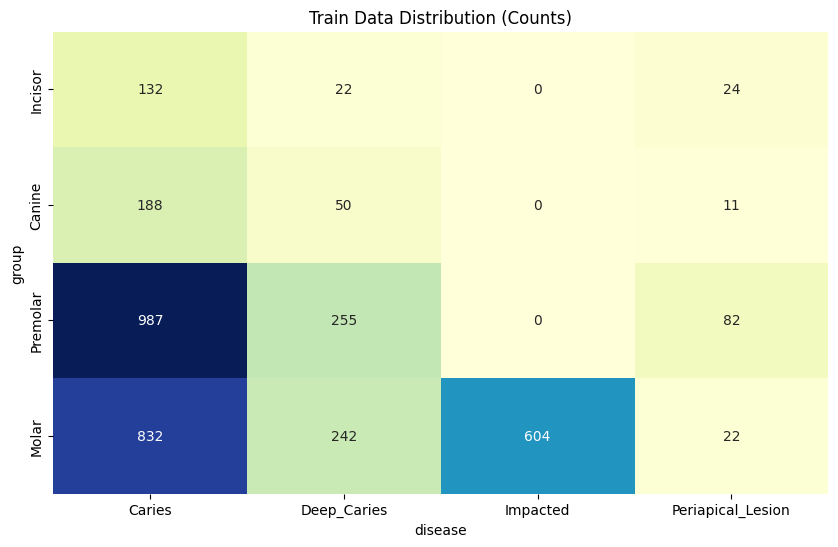

In [2]:
# --- 1. PIVOT TABLE (TRAIN) ---
if not df.empty:
    train_df = df[df['split'] == 'Train']
    pivot_train = train_df.pivot_table(index='group', columns='disease', values='class', aggfunc='count', fill_value=0)
    
    # Reorder columns/index for better view
    row_order = ['Incisor', 'Canine', 'Premolar', 'Molar']
    col_order = ['Caries', 'Deep_Caries', 'Impacted', 'Periapical_Lesion']
    
    # Filter existing cols only
    row_order = [r for r in row_order if r in pivot_train.index]
    col_order = [c for c in col_order if c in pivot_train.columns]
    
    pivot_train = pivot_train.loc[row_order, col_order]
    
    print("\n--- TRAIN DATASET COUNT MATRIX ---")
    display(pivot_train)
    
    # Heatmap of Train
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_train, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
    plt.title("Train Data Distribution (Counts)")
    plt.show()

In [3]:
# --- 2. DETAILED LIST (TRAIN + VAL) ---
if not df.empty:
    counts = df.groupby(['split', 'class']).size().reset_index(name='count')
    counts = counts.sort_values(by=['split', 'count'], ascending=[False, False])

    print("\n--- DETAILED CLASS COUNTS ---")
    # Format as a table
    print(f"{'Split':<10} {'Class Name':<30} {'Count':<5}")
    print("-"*50)
    for _, row in counts.iterrows():
        print(f"{row['split']:<10} {row['class']:<30} {row['count']:<5}")


--- DETAILED CLASS COUNTS ---
Split      Class Name                     Count
--------------------------------------------------
Val        Premolar_Caries                49   
Val        Molar_Impacted                 40   
Val        Molar_Caries                   37   
Val        Molar_Deep_Caries              13   
Val        Premolar_Deep_Caries           11   
Val        Canine_Caries                  6    
Val        Incisor_Caries                 6    
Val        Premolar_Periapical_Lesion     5    
Val        Canine_Deep_Caries             3    
Val        Incisor_Deep_Caries            3    
Val        Canine_Periapical_Lesion       2    
Val        Molar_Periapical_Lesion        2    
Train      Premolar_Caries                987  
Train      Molar_Caries                   832  
Train      Molar_Impacted                 604  
Train      Premolar_Deep_Caries           255  
Train      Molar_Deep_Caries              242  
Train      Canine_Caries                  188  
Train 